Introduction:

Sabrina and I are Microbiology majors, and have served as teaching assistants for MCB3023L; a core Microbiology laboratory class. A key part of the class is the lab practical, which constitutes a large part of the students' grades. It is notorious for being long and difficult.

We wanted to investigate factors potentially related to performance on the lab practical so that we could help our professor and her future students.

Data Collection:

We started off by creating a survey for MCB3023L asking several questions related to 1) their letter grade performance on the practical and 2) their studying/learning habits related to the lab practical.


Now, to help you get an idea of what the survey was like, here is a look at the questions asked on the survey: 

How often did you pay close attention during lab sessions?

How many times did you come into the lab outside of class to practice techniques?

How confident were you in your lab techniques before the practical? (rate 1-5 )

How anxious were you about the lab practical? (rate 1-5 )

How many hours per week did you study or review lab materials?

Helpfulness in Studying: Lab Manual (rate 1-5 stars)

Helpfulness in Studying: Quizlet (rate 1-5 stars)

Helpfulness in Studying: Lab Slides (rate 1-5 stars)

Helpfulness in Studying: ELNs (rate 1-5 stars)

Helpfulness in Studying: ChatGPT (rate 1-5 stars)

Do you or have you worked or volunteered in a lab setting outside of MCB3023L? (yes or no)

What grade did you receive on the lab practical? ← (Target!! What we want to predict!! Asked as Letter Grade, not Numerical grade)

We then had to obtain IRB-exemption (since we were collecting data off of people) and sponsorship from our professor of whom we TA'd for. It could be argued that we don't actually need this since this is for educational purposes and not for research publication, but we decided we would do this for ethical purposes, just in case. 

Additionally, all the data collected was anonymous.


Survey Distribution: 

The next part involved contacting three professors who teach MCB3023L and requesting they distribute the survey to their students. It was the most essential part of our project. Without data, we don't really have a solid project. Additionally, the number of responses we got largely impacts what models we can even consider using. 

We ended up collecting 82 responses total. Was it what we wanted? No. But this is how the real world works sometimes, and so we had to make do. 

Because of how many responses we got, we decided we could NOT use a deep neural network. We would have to stick with using Logistic Regression, Random Forest, and Decision Trees.

## Data Preprocessing: Load & Clean Columns

Okay so first we’re loading in the CSV file from our survey. Some of the column names are way too long and arguably annoying to work with, so we’re renaming them to something easier. We’re also dropping the timestamp and the confirmation checkbox since they’re not useful for our analysis. Those are just the questions that address when the person took the survey and if they want to take the survey.


In [ ]:
import pandas as pd

# Load the raw CSV file
df = pd.read_csv("MCB3032L (Responses) - Form Responses final.csv")

# Rename columns to something more readable
df.columns = [
    "timestamp",
    "attention_during_lab",
    "lab_practice_times",
    "confidence_before_practical",
    "anxiety_about_practical",
    "study_hours_per_week",
    "helpfulness_lab_manual",
    "helpfulness_quizlet",
    "helpfulness_lab_slides",
    "helpfulness_eln",
    "helpfulness_chatgpt",
    "prior_lab_experience",
    "lab_practical_grade",
    "survey_confirmation"
]

# Drop unnecessary columns
df = df.drop(columns=["timestamp", "survey_confirmation"], errors="ignore")

# Drop "Prefer not to say" rows from grade column. Why? If this is the target variable, and the person did not answer, the rest of their data is not very useful to us. 
df = df[df["lab_practical_grade"].str.strip().str.lower() != "prefer not to say"]

# Display the first few rows
df.head()


,attention_during_lab,lab_practice_times,confidence_before_practical,anxiety_about_practical,study_hours_per_week,helpfulness_lab_manual,helpfulness_quizlet,helpfulness_lab_slides,helpfulness_eln,helpfulness_chatgpt,prior_lab_experience,lab_practical_grade
0,most of the time,0 times,5,3,less than 1 hour,3.0,1.0,4.0,5,1.0,yes,A (90-100)
1,most of the time,2-3 times,5,2,1-2 hours,1.0,1.0,2.0,1,1.0,yes,D (60-69)
2,most of the time,2-3 times,4,2,1-2 hours,3.0,1.0,5.0,5,4.0,yes,B (80-89)
3,most of the time,2-3 times,3,3,less than 1 hour,2.0,2.0,5.0,4,1.0,yes,B (80-89)
4,most of the time,2-3 times,3,5,less than 1 hour,2.0,1.0,3.0,4,4.0,yes,B (80-89)


## Converting Survey Answers to Numbers

 Stuff like “most of the time” and “1-2 hours” needs to be mapped to something a model can understand, as well as to keep some continuity aspects. We made custom mappings for each of these based on how they rank in terms of effort or frequency by making them averages (eg 1-2 hours represented as 1.5 hours)

One example important to note is that we changed the yes or no to binary because the model is not going to understand yes or no, but it will understand 1 and 0s.

We also cleaned up the grade column so it just says A, B, C, D, or F. 


In [2]:
# Define mappings
attention_map = {
    "always": 5,
    "most of the time": 4,
    "sometimes": 3,
    "rarely": 2,
    "never": 1
}

lab_practice_map = {
    "0 times": 0,
    "1 time": 1,
    "2-3 times": 2.5,
    "4-5 times": 4.5,
    "6+ times": 6
}

study_hours_map = {
    "less than 1 hour": 0.5,
    "1-2 hours": 1.5,
    "3-4 hours": 3.5,
    "5+ hours": 5
}

lab_experience_map = {
    "yes": 1,
    "no": 0
}

# Apply the mappings
df["attention_during_lab"] = df["attention_during_lab"].str.strip().map(attention_map)
df["lab_practice_times"] = df["lab_practice_times"].str.strip().map(lab_practice_map)
df["study_hours_per_week"] = df["study_hours_per_week"].str.strip().map(study_hours_map)
df["prior_lab_experience"] = df["prior_lab_experience"].str.strip().map(lab_experience_map)
df["lab_practical_grade"] = df["lab_practical_grade"].str.extract(r'([A-F])')

# Check the cleaned version
df.head()


,attention_during_lab,lab_practice_times,confidence_before_practical,anxiety_about_practical,study_hours_per_week,helpfulness_lab_manual,helpfulness_quizlet,helpfulness_lab_slides,helpfulness_eln,helpfulness_chatgpt,prior_lab_experience,lab_practical_grade
0,4,0.0,5,3,0.5,3.0,1.0,4.0,5,1.0,1,A
1,4,2.5,5,2,1.5,1.0,1.0,2.0,1,1.0,1,D
2,4,2.5,4,2,1.5,3.0,1.0,5.0,5,4.0,1,B
3,4,2.5,3,3,0.5,2.0,2.0,5.0,4,1.0,1,B
4,4,2.5,3,5,0.5,2.0,1.0,3.0,4,4.0,1,B


In [ ]:
#This is just to get a feel for how many grades are in each column.

# Optional: simplify to just letters and sort manually
df["lab_practical_grade"] = df["lab_practical_grade"].str.extract(r'([A-F])')

# Count and sort by letter grade
df["lab_practical_grade"].value_counts().reindex(["A", "B", "C", "D", "F"])


lab_practical_grade
A    22
B    30
C    15
D     7
F     2
Name: count, dtype: int64


## Handling Missing Values

Since we don’t have a ton of data, we can’t just drop rows that have missing values (besides the one with ONLY one sample). So instead, we’ll fill in the missing stuff.

- For number-based questions (like study hours or confidence), we’ll fill missing values with the **median**.
- If anyone didn’t report their **grade**, we’ll drop just that row — we can’t use it to train the model anyway.


In [4]:
# Check for missing values in each column
print("Missing values per column:\n")
print(df.isnull().sum())

# Fill numeric columns with the median
num_cols = df.select_dtypes(include=["float64", "int64"]).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# If any rows are missing the target grade, drop those (we can't train on them)
df = df.dropna(subset=["lab_practical_grade"])

# For any remaining categorical data, fill NaNs with the mode (most common value)
cat_cols = df.select_dtypes(include=["object"]).columns
df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])

# Double-check for any remaining missing values
print("\nAny missing values left?", df.isnull().values.any())
print(f"Final dataset shape: {df.shape}")



Missing values per column:

attention_during_lab           0
lab_practice_times             0
confidence_before_practical    0
anxiety_about_practical        0
study_hours_per_week           0
helpfulness_lab_manual         1
helpfulness_quizlet            2
helpfulness_lab_slides         2
helpfulness_eln                0
helpfulness_chatgpt            3
prior_lab_experience           0
lab_practical_grade            0
dtype: int64

Any missing values left? False
Final dataset shape: (76, 12)


## Quick Visuals to Explore the Data

Before we build any models, it’s a good idea to look at the data a bit. Here’s a bar chart showing how many people got each grade, and a boxplot that shows if there’s any pattern between how many hours people studied and what grade they got.


/tmp/ipykernel_80001/1166850151.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="lab_practical_grade", data=df, order=["A", "B", "C", "D", "F"], palette="viridis")


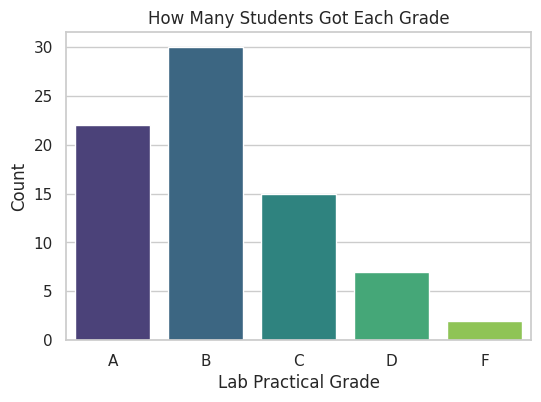

/tmp/ipykernel_80001/1166850151.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="lab_practical_grade", y="study_hours_per_week", data=df, order=["A", "B", "C", "D", "F"], palette="pastel")


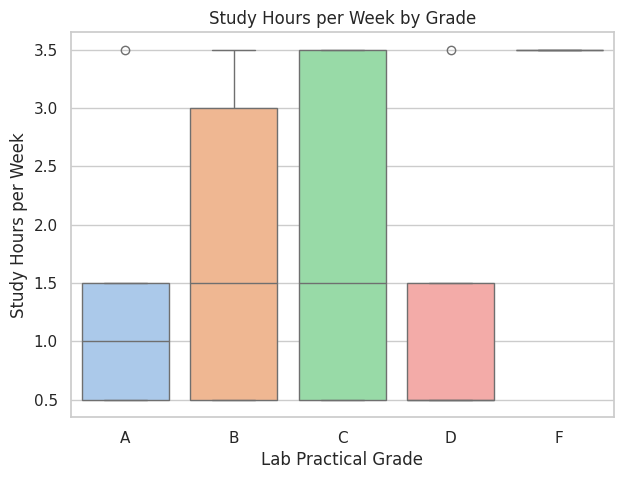

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set(style="whitegrid")

# Bar plot: count of each grade
plt.figure(figsize=(6, 4))
sns.countplot(x="lab_practical_grade", data=df, order=["A", "B", "C", "D", "F"], palette="viridis")
plt.title("How Many Students Got Each Grade")
plt.xlabel("Lab Practical Grade")
plt.ylabel("Count")
plt.show()

# Boxplot: study hours vs grade
plt.figure(figsize=(7, 5))
sns.boxplot(x="lab_practical_grade", y="study_hours_per_week", data=df, order=["A", "B", "C", "D", "F"], palette="pastel")
plt.title("Study Hours per Week by Grade")
plt.xlabel("Lab Practical Grade")
plt.ylabel("Study Hours per Week")
plt.show()


## Looking at All the Features Together

We’re going to make a pairplot now. It shows all the relationships between our features (like confidence, anxiety, study hours, etc.). The dots are colored by what grade the student got. 

This is helpful to spot patterns — like whether higher study hours and confidence cluster around A’s, or if anxiety is all over the place. Even if we don’t get perfect separation, it gives us an idea of what features might matter.


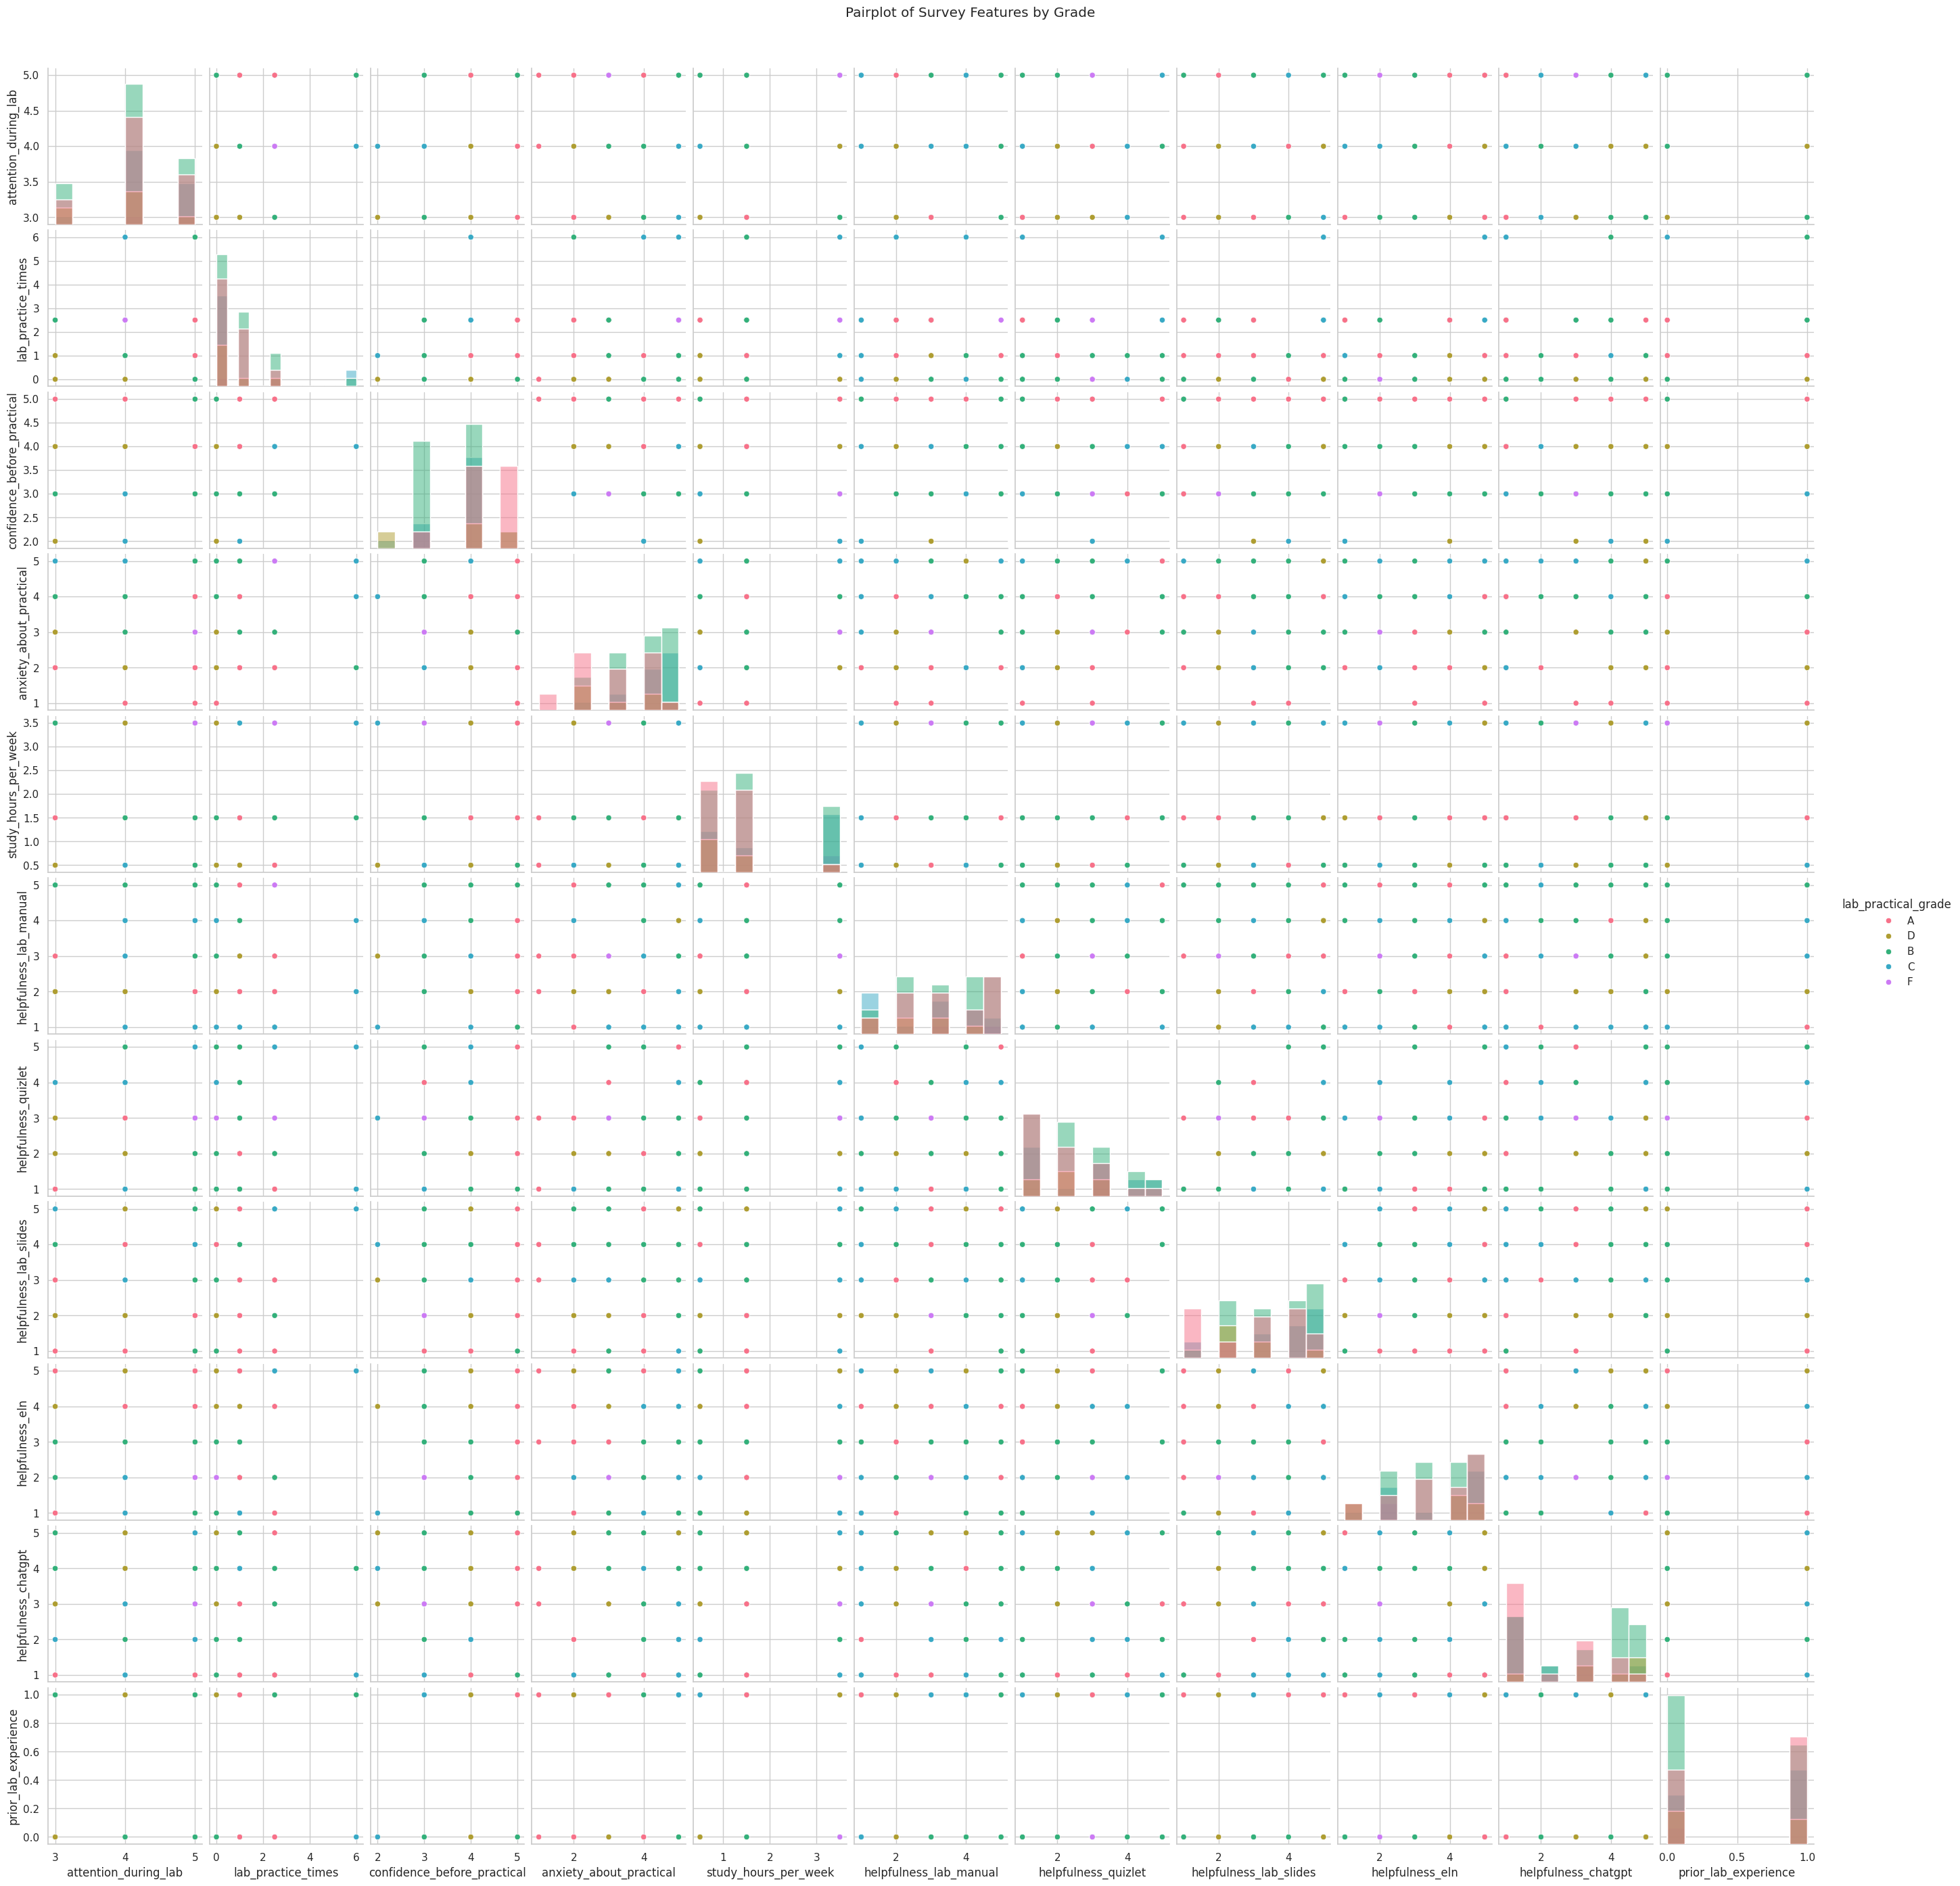

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# Grab just the numeric features (drop grade for now)
features_for_pairplot = df.drop(columns=["lab_practical_grade"]).select_dtypes(include=[float, int])

# Add grade back in for coloring
pairplot_data = features_for_pairplot.copy()
pairplot_data["lab_practical_grade"] = df["lab_practical_grade"]

# Plot
sns.pairplot(pairplot_data, hue="lab_practical_grade", palette="husl", diag_kind="hist")
plt.suptitle("Pairplot of Survey Features by Grade", y=1.02)
plt.show()



## Quick Look at Some Results So Far

Before we jump into splitting the data or running models, here are a few early visuals based on the cleaned survey data:

- The **grade distribution** shows most students got A’s or B’s, with a few lower grades mixed in.
- The **study hours boxplot** suggests that higher study hours don’t necessarily mean better grades—C students studied more on average than A students.
- The **pairplot** helps us explore relationships between variables. It’s a big messy grid of scatterplots, but sometimes you can see clusters that suggest which variables might help us separate the different grade categories.

We'll keep all of this in mind as we move into modeling.
So yeah, looking at the data... clearly study time alone doesn’t explain who gets an A and who doesn’t. That’s why we’re going to train some to see if we can potentially pick up on patterns that actually matter.


## Train-Test Split + First Model (Logistic Regression)

Now it’s time to train our first model: **Logistic Regression**. We chose this model because:

- It’s simple to understand
- It runs fast
- It provides a good baseline to understand which features matter

Logistic regression is typically used for binary classification, but it can also handle multiple classes (A/B/C/D/F) using *one-vs-rest*. This approach builds one model for each class, distinguishing it from the others.

### Why 70/30 Split?
We decided to use a **70/30 split** instead of the usual 80/20 to ensure we had a larger test set. With 23 samples in the test set, we can get a more reliable estimate of model performance without reducing the amount of training data too much.

### What we’re doing here:
1. Split the dataset into training and testing sets. We’ll use **70%** of the data for training and save **30%** to test the model’s performance on unseen data.
2. Train the logistic regression model on the training data.
3. Use the trained model to make predictions on the test set.
4. Evaluate the model’s performance by checking accuracy and examining a confusion matrix to see where it’s getting grades right or wrong.

We’ve made a couple of adjustments to ensure smoother results:
- **Suppressing warnings** for undefined precision, which can happen when the model doesn’t predict certain grades (this is common in small datasets).
- **Handling label mismatch** in the confusion matrix by ensuring it only shows the labels present in the test set.



Accuracy: 34.78%
Classification Report:
              precision    recall  f1-score   support

           A       0.50      0.57      0.53         7
           B       0.43      0.33      0.38         9
           C       0.12      0.25      0.17         4
           D       0.00      0.00      0.00         2
           F       0.00      0.00      0.00         1

    accuracy                           0.35        23
   macro avg       0.21      0.23      0.21        23
weighted avg       0.34      0.35      0.34        23



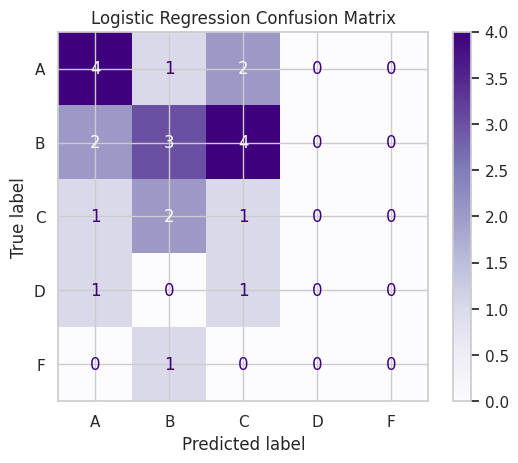

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Define features and target
X = df.drop(columns=["lab_practical_grade"])
y = df["lab_practical_grade"]

# Step 2: Train-test split (70/30)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# Step 3: Train the logistic regression model
logreg = LogisticRegression(max_iter=10000, solver="lbfgs")
logreg.fit(X_train, y_train)

# Step 4: Make predictions
y_pred = logreg.predict(X_test)

# Step 5: Evaluate performance
print(f"Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

# Step 6: Handle label mismatch in confusion matrix
labels_in_test = np.unique(np.concatenate([y_test, y_pred]))

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred, labels=labels_in_test),
    display_labels=labels_in_test
).plot(cmap="Purples")

plt.title("Logistic Regression Confusion Matrix")
plt.show()


## Logistic Regression Results

We ran Logistic Regression with the **70/30 split**, and here’s what we got:

- **Accuracy**: 34.78%
- The model did okay at predicting A’s, but struggled with the other grades.
- **Precision** and **recall** for lower grades (C, D, F) were pretty bad.
- It mostly predicted A’s and B’s, as seen in the classification report.

So, **Logistic Regression** worked fine as a baseline model, but it’s clear it’s not cutting it for this dataset. The class imbalance and the complexity of the data likely made it too simple for capturing meaningful patterns.

### Key Takeaways:
- Logistic Regression is **missing a lot of lower grades** (C, D, F).
- We need something **more complex** to dig deeper into this data.


## Feature Selection and Scaling Before Re-running Logistic Regression

After our initial Logistic Regression model, we noticed that the features could be simplified and standardized. Here's what we’ll do next:

1. **Select the top 5 features** using `SelectKBest` based on their ability to predict lab practical grades.
2. **Scale** the selected features to ensure they’re on the same scale for optimal performance.
3. **Re-train** the Logistic Regression model using only the selected and scaled features.

This should help the model focus on the most relevant information and potentially improve performance.


Accuracy (scaled, best features): 39.13%
Classification Report (scaled, best features):
              precision    recall  f1-score   support

           A       0.40      0.29      0.33         7
           B       0.38      0.67      0.48         9
           C       0.50      0.25      0.33         4
           D       0.00      0.00      0.00         2
           F       0.00      0.00      0.00         1

    accuracy                           0.39        23
   macro avg       0.26      0.24      0.23        23
weighted avg       0.36      0.39      0.35        23



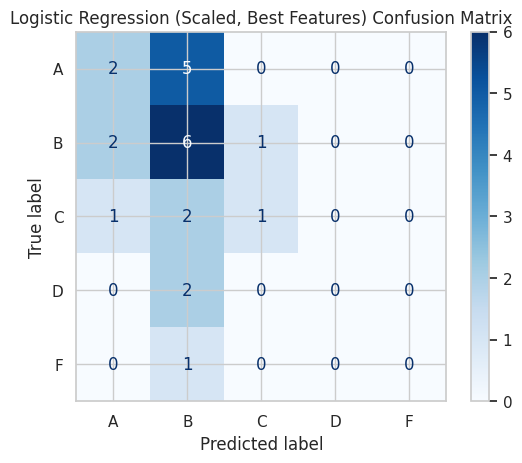

In [8]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Select the top 5 features (using SelectKBest)
X = df[[
    'confidence_before_practical',
    'anxiety_about_practical',
    'study_hours_per_week',
    'helpfulness_lab_slides',
    'helpfulness_chatgpt'
]]
y = df["lab_practical_grade"]

# Apply SelectKBest to get top 5 features
selector = SelectKBest(score_func=f_classif, k=5)
X_selected = selector.fit_transform(X, y)

# Step 2: Train-test split (70/30)
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.3, stratify=y, random_state=42
)

# Step 3: Scale the selected features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Fit on training data and transform
X_test_scaled = scaler.transform(X_test)  # Only transform test data

# Step 4: Re-train logistic regression on scaled data
logreg_scaled = LogisticRegression(max_iter=10000, solver="lbfgs")
logreg_scaled.fit(X_train_scaled, y_train)

# Step 5: Predict and evaluate
y_pred_scaled = logreg_scaled.predict(X_test_scaled)

# Print accuracy and classification report
print(f"Accuracy (scaled, best features): {accuracy_score(y_test, y_pred_scaled)*100:.2f}%")
print("Classification Report (scaled, best features):")
print(classification_report(y_test, y_pred_scaled, zero_division=0))

# Step 6: Confusion matrix with dynamic labels
labels_in_scaled_test = np.unique(np.concatenate([y_test, y_pred_scaled]))

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_scaled, labels=labels_in_scaled_test),
    display_labels=labels_in_scaled_test
).plot(cmap="Blues")

plt.title("Logistic Regression (Scaled, Best Features) Confusion Matrix")
plt.show()


## Logistic Regression with Scaled Features (Best Features) – Results

After re-running **Logistic Regression** using only the top 5 selected features and scaling the data, we got an **accuracy of 39.13%**. 

Key Observations:
- **B** grades performed the best (67% recall), but it’s still far from ideal.
- **A**, **C**, **D**, and **F** grades had poor precision and recall, indicating that the model struggled to correctly predict these categories.
- Scaling and selecting features didn’t drastically improve performance compared to the initial model.

We’re still missing the mark with the lower grades, so we may need to try **more complex models** to improve the results.


## Decision Tree Classifier

Now, we’re going to try a **Decision Tree Classifier**, which is a non-linear model that can capture more complex patterns than Logistic Regression. Decision Trees don't require scaling, and they can be quite effective at identifying thresholds in the data.

We’ll train it on the same **70/30 split** and **top 5 selected features**, then evaluate its performance.


Accuracy (Decision Tree): 34.78%
Classification Report (Decision Tree):
              precision    recall  f1-score   support

           A       0.75      0.43      0.55         7
           B       0.50      0.33      0.40         9
           C       0.25      0.50      0.33         4
           D       0.00      0.00      0.00         2
           F       0.00      0.00      0.00         1

    accuracy                           0.35        23
   macro avg       0.30      0.25      0.26        23
weighted avg       0.47      0.35      0.38        23



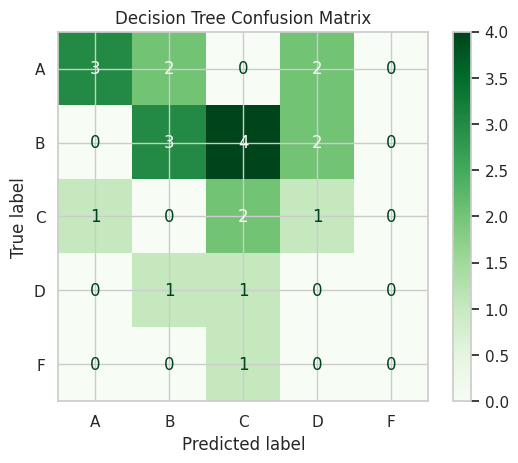

In [9]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Train the decision tree model
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)

# Step 2: Make predictions
y_pred_tree = tree.predict(X_test)

# Step 3: Evaluate performance
print(f"Accuracy (Decision Tree): {accuracy_score(y_test, y_pred_tree)*100:.2f}%")
print("Classification Report (Decision Tree):")
print(classification_report(y_test, y_pred_tree, zero_division=0))

# Step 4: Confusion matrix
labels_in_tree_test = np.unique(np.concatenate([y_test, y_pred_tree]))

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_tree, labels=labels_in_tree_test),
    display_labels=labels_in_tree_test
).plot(cmap="Greens")

plt.title("Decision Tree Confusion Matrix")
plt.show()


## Decision Tree Results

After running the **Decision Tree Classifier**, we achieved an **accuracy of 34.78%**.

Key Observations:
- **A** grades had decent performance with **43% recall**, but still far from ideal.
- **C** grades showed a better recall (**50%**), though still not perfect.
- The model struggled with **D** and **F** grades, showing **0% recall**.
- The overall performance is similar to Logistic Regression, suggesting that a **simpler model** may not capture the complexity of the data.

This shows that Decision Trees can capture more complex patterns but still face challenges with **class imbalance** and **underrepresented grades**.


## Random Forest Classifier

Next, we’ll try a **Random Forest Classifier**, which combines multiple decision trees to improve model performance. By averaging the predictions of multiple trees, it tends to be less prone to overfitting than a single decision tree.

We’ll train it on the same **70/30 split** and **top 5 selected features**, and evaluate its performance.


Accuracy (Random Forest): 52.17%
Classification Report (Random Forest):
              precision    recall  f1-score   support

           A       0.57      0.57      0.57         7
           B       0.54      0.78      0.64         9
           C       0.33      0.25      0.29         4
           D       0.00      0.00      0.00         2
           F       0.00      0.00      0.00         1

    accuracy                           0.52        23
   macro avg       0.29      0.32      0.30        23
weighted avg       0.44      0.52      0.47        23



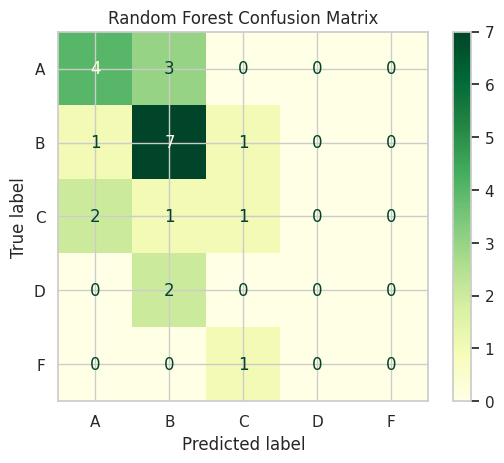

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Train the random forest model
forest = RandomForestClassifier(random_state=42, n_estimators=100)
forest.fit(X_train, y_train)

# Step 2: Make predictions
y_pred_forest = forest.predict(X_test)

# Step 3: Evaluate performance
print(f"Accuracy (Random Forest): {accuracy_score(y_test, y_pred_forest)*100:.2f}%")
print("Classification Report (Random Forest):")
print(classification_report(y_test, y_pred_forest, zero_division=0))

# Step 4: Confusion matrix
labels_in_forest_test = np.unique(np.concatenate([y_test, y_pred_forest]))

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_forest, labels=labels_in_forest_test),
    display_labels=labels_in_forest_test
).plot(cmap="YlGn")

plt.title("Random Forest Confusion Matrix")
plt.show()


## Random Forest Results

After running the **Random Forest Classifier**, we achieved an **accuracy of 52.17%**, the best so far.

Key Observations:
- **B** grades showed strong recall (**78%**), which is a solid result.
- **A** grades also performed decently with **57% recall**.
- However, the model struggled with **C**, **D**, and **F** grades, showing very low recall for these classes.
- Overall, **Random Forest** provides better performance than Logistic Regression and Decision Trees.

This suggests that **Random Forest** is better at handling class imbalance and complexity in the data but still struggles with underrepresented grades.


## Gradient Boosting Classifier

Now, we’re going to run **Gradient Boosting**, which builds a series of decision trees where each new tree tries to correct the mistakes made by the previous one. It’s often more accurate than a single decision tree or even a random forest.

We’ll train **Gradient Boosting** on the **70/30 split** and **top 5 selected features**, then evaluate its performance.


Accuracy (Gradient Boosting): 56.52%
Classification Report (Gradient Boosting):
              precision    recall  f1-score   support

           A       0.60      0.43      0.50         7
           B       0.70      0.78      0.74         9
           C       0.50      0.50      0.50         4
           D       0.00      0.00      0.00         2
           F       0.33      1.00      0.50         1

    accuracy                           0.57        23
   macro avg       0.43      0.54      0.45        23
weighted avg       0.56      0.57      0.55        23



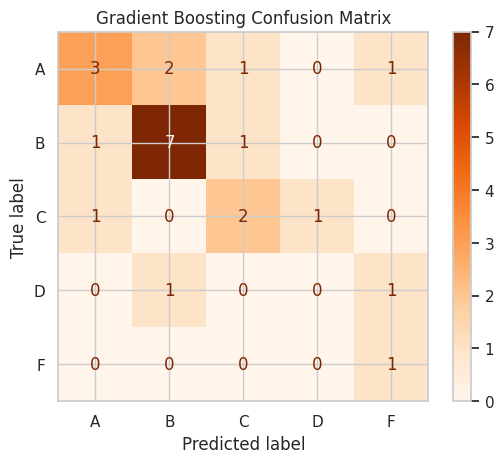

In [11]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Train the Gradient Boosting model
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)

# Step 2: Make predictions
y_pred_gb = gb.predict(X_test)

# Step 3: Evaluate performance
print(f"Accuracy (Gradient Boosting): {accuracy_score(y_test, y_pred_gb)*100:.2f}%")
print("Classification Report (Gradient Boosting):")
print(classification_report(y_test, y_pred_gb, zero_division=0))

# Step 4: Confusion matrix
labels_in_gb_test = np.unique(np.concatenate([y_test, y_pred_gb]))

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_gb, labels=labels_in_gb_test),
    display_labels=labels_in_gb_test
).plot(cmap="Oranges")

plt.title("Gradient Boosting Confusion Matrix")
plt.show()


## Gradient Boosting Results

The **Gradient Boosting** model performed well, achieving an **accuracy of 56.52%**.

Key Observations:
- **B** grades had strong performance with **78% recall** and **74% F1-score**.
- **F** grades were predicted perfectly with **100% recall**, but this is because there was only 1 sample.
- **A** and **C** grades had mixed performance with reasonable recall, but **D** grades were not predicted at all.

Overall, **Gradient Boosting** is the best-performing model so far and captures more complexity in the data compared to simpler models.
